In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
# Скачать данные MNIST
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

In [3]:
# Преобразование измерений и нормализация данных
x_train = x_train_org.reshape(x_train_org.shape[0], 28 * 28).astype('float32') / 255.0
x_test = x_test_org.reshape(x_test_org.shape[0], 28 * 28).astype('float32') / 255.0

In [4]:
# Преобразование в one_hot_encoding
CLASS_COUNT = 10
y_train = to_categorical(y_train_org, CLASS_COUNT)
y_test = to_categorical(y_test_org, CLASS_COUNT)

In [5]:
print(f'Форма обучающих данных: {x_train.shape} -> {x_train_org.shape}')
print(f'Форма тестовых данных: {x_test.shape} -> {x_test_org.shape}')

Форма обучающих данных: (60000, 784) -> (60000, 28, 28)
Форма тестовых данных: (10000, 784) -> (10000, 28, 28)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
model = Sequential() 
model.add(Dense(800, input_dim=28 * 28, activation='relu'))  # слой ввода 
model.add(Dense(400, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))  # слой вывода

c:\Users\asgat\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # Компиляция модели

In [9]:
model.fit(x_train, y_train, batch_size=128, epochs=15, verbose=1)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8898 - loss: 0.3743
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9759 - loss: 0.0758
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9839 - loss: 0.0485
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9894 - loss: 0.0329
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9925 - loss: 0.0238
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9938 - loss: 0.0180
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9946 - loss: 0.0163
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9949 - loss: 0.0151
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9955 - loss: 0.0142
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9959 - loss: 0.0111
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9963 - loss: 0.0119
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

In [10]:
model.save_weights('model.weights.h5')
model.load_weights('model.weights.h5')

In [11]:
score = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {score[0]}')
print(f'Test accuracy: {score[1]}')

Test loss: 0.08795274794101715
Test accuracy: 0.9804999828338623


In [27]:
from PIL import Image

In [28]:
image_path = './Number2.jpg'  
img = Image.open(image_path)
img = img.resize((28, 28))

In [32]:
img_array = np.array(img.convert('L'))

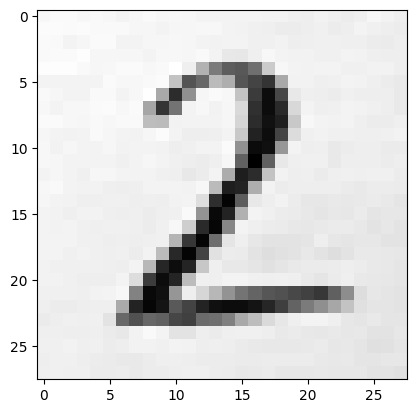

In [33]:
plt.imshow(img_array.reshape(28,28), cmap='gray')

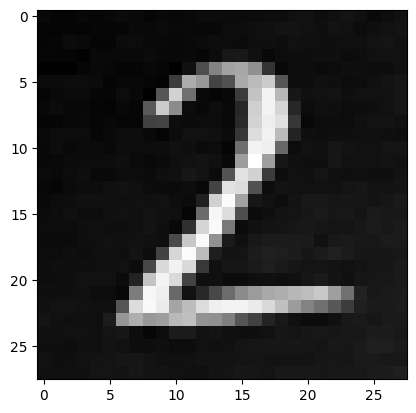

In [34]:
img_array = img_array.reshape(1, 28 * 28).astype('float32') / 255.0 
img_array = 1 - img_array 
plt.imshow(img_array.reshape(28, 28), cmap='gray')
plt.show()

In [35]:
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
print(prediction)

1/1 [==============================] - 0s 35ms/step
[[1.2853011e-03 1.9559715e-02 9.6867955e-01 5.6225667e-03 2.9646933e-06
  1.6361611e-03 2.3964576e-04 2.8023282e-03 1.6998244e-04 1.8927100e-06]]


In [31]:
print(f'Predicted digit: {predicted_class}')

Predicted digit: 2
